In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt

# Period

In [2]:
iyear = 1981
fyear = 2015
models = ['APHRO','GPCP','CRU','CHIRPS','HARv2','ERA5']
domains = ['HMA','HK','SL','TP','CH','SEH']

# TP timeseries DATASETS & DOMAINS

## JJAS

In [3]:
tp_datasets = {}
stats_datasets = {}

path = '/bettik/PROJECTS/pr-regional-climate/bricej/results/timeseries/'

for model in models:
    tp_datasets[model] = {}
    stats_datasets[model] = {}
    for domain in domains:
        tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_JJAS_{domain}_1981-2015_{model}.csv')
        stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_JJAS_{domain}_1981-2015_{model}.csv')

,HMA,HK,SL,TP,CH,SEH
APHRO,2.46,10.23,6.11,1.45,-5.12,-2.37
GPCP,0.50,1.52,3.15,1.75,-7.89,-2.05
CRU,0.47,0.71,1.04,0.86,-4.22,-0.40
CHIRPS,2.59,0.31,-4.03,3.92,0.47,4.54
HARv2,0.94,-0.18,3.41,2.32,7.23,-6.04
ERA5,0.24,-0.60,2.13,2.53,7.39,-10.00


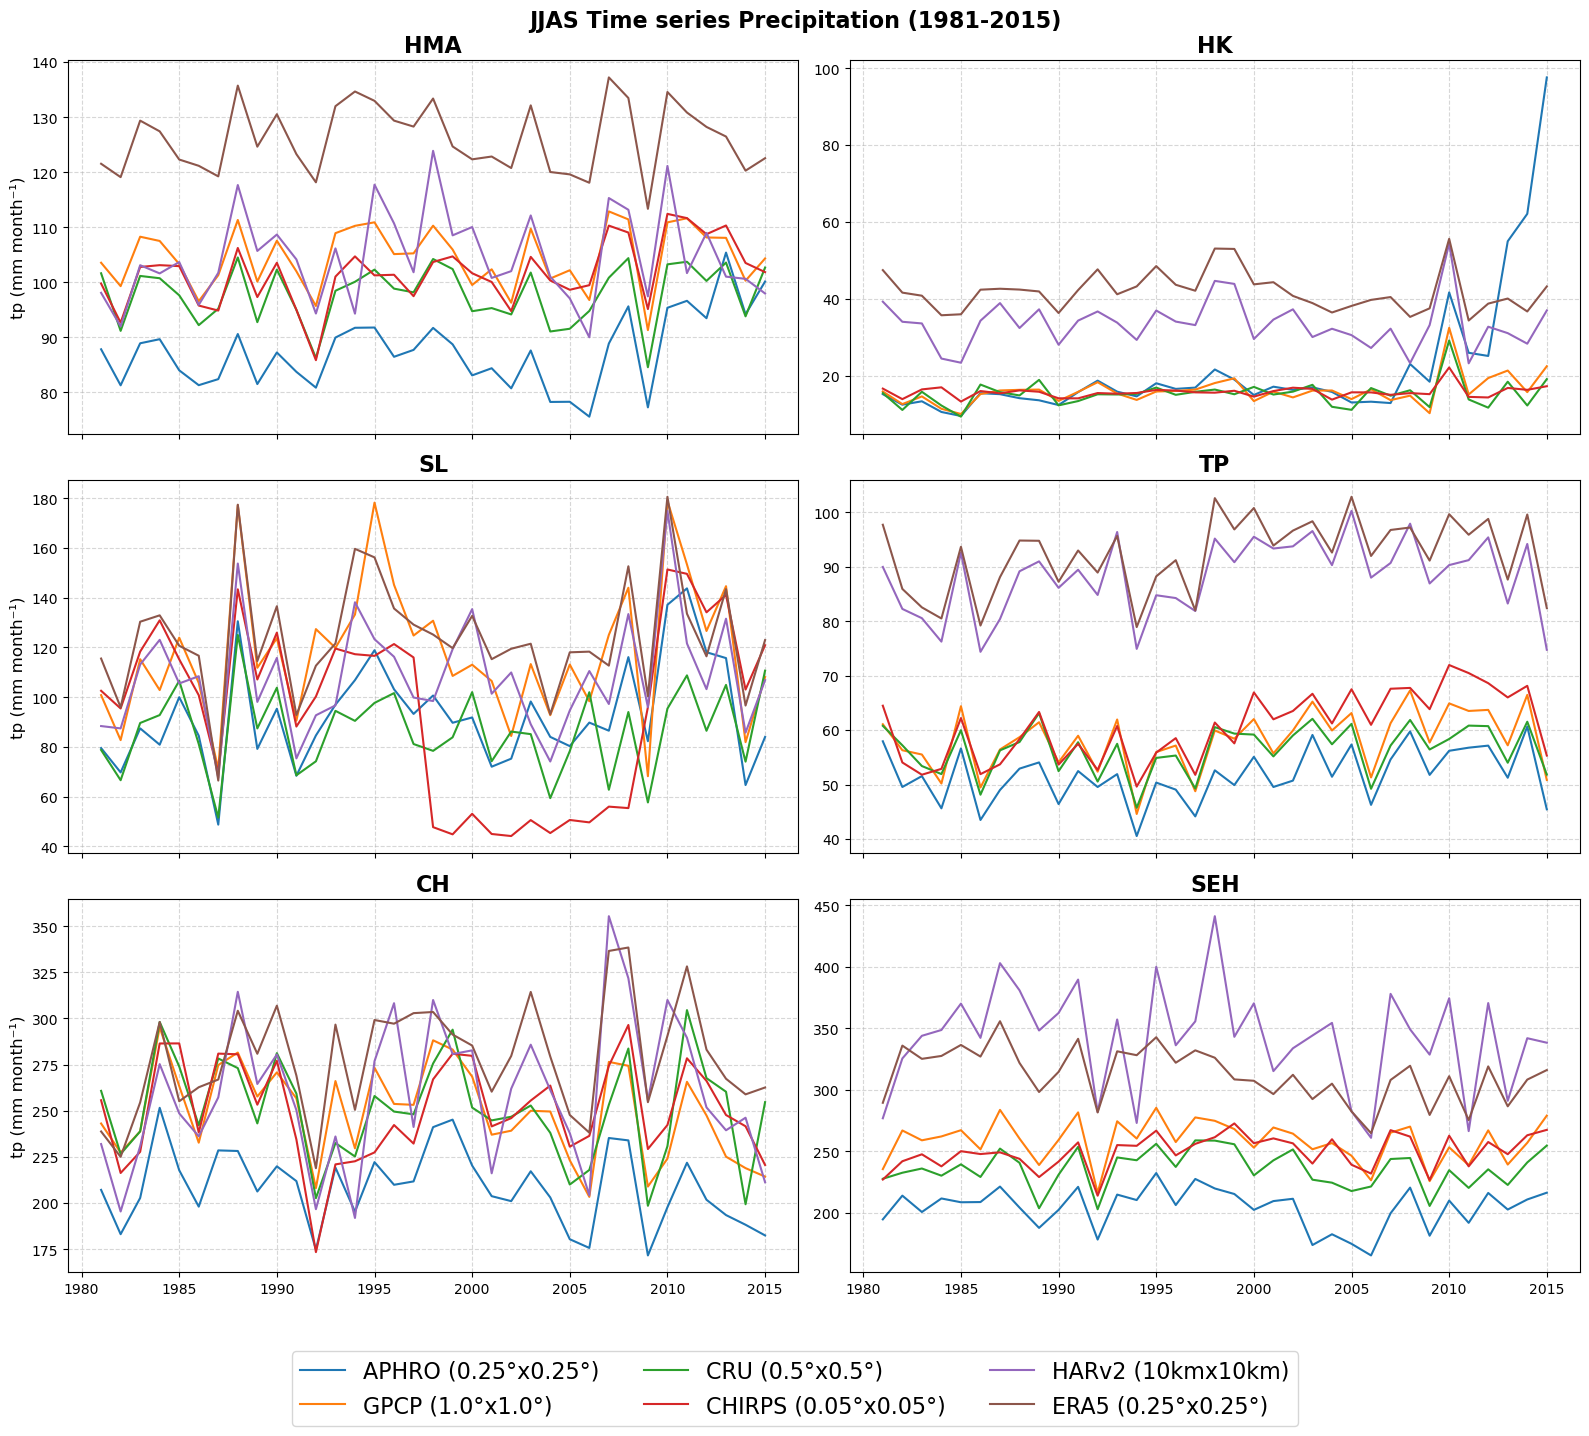

In [4]:
resolutions = {'APHRO': '0.25°x0.25°',
               'GPCP': '1.0°x1.0°',
               'CRU': '0.5°x0.5°',
               'CHIRPS': '0.05°x0.05°',
               'HARv2': '10kmx10km',
               'ERA5': '0.25°x0.25°'}

#============== tableau des p-values ==========================

table = pd.DataFrame(index=models, columns=domains)
pvals = pd.DataFrame(index=models, columns=domains)

for model in models:
    for dom in domains:

        df = stats_datasets[model][dom]

        slope = df.loc[df['stat']=='slope','value'].values[0] * 10
        pval  = df.loc[df['stat']=='p_value','value'].values[0]

        table.loc[model, dom] = slope
        pvals.loc[model, dom] = pval

def bold_sig(val, p):
    if p < 0.05:
        return 'font-weight: bold'
    return ''

styled_table = table.style.apply(
    lambda x: [bold_sig(v, pvals.loc[x.name, col]) for col, v in x.items()],
    axis=1
).format("{:.2f}")

display(styled_table)

# ====================== plot time series ========================

fig, axes = plt.subplots(3, 2, figsize=(16,14))
axes = axes.flatten()

for i, dom in enumerate(domains):

    ax = axes[i]

    for model in models:
        da = tp_datasets[model][dom]
        ax.plot(da['year'], da['tp'], linestyle='-', label=f'{model} ({resolutions[model]})', linewidth=1.5)

    ax.set_title(dom, fontsize=16, weight="bold")
    
    if i in [0, 2, 4]:  # colonne gauche
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
    if i in [4, 5]:  # ligne du bas
        ax.tick_params(labelbottom=True)
    if i in [0,1,2,3]:
        ax.tick_params(labelbottom=False)
    
    ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
fig.suptitle(f'JJAS Time series Precipitation ({iyear}-{fyear})', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

## BOX PLOT

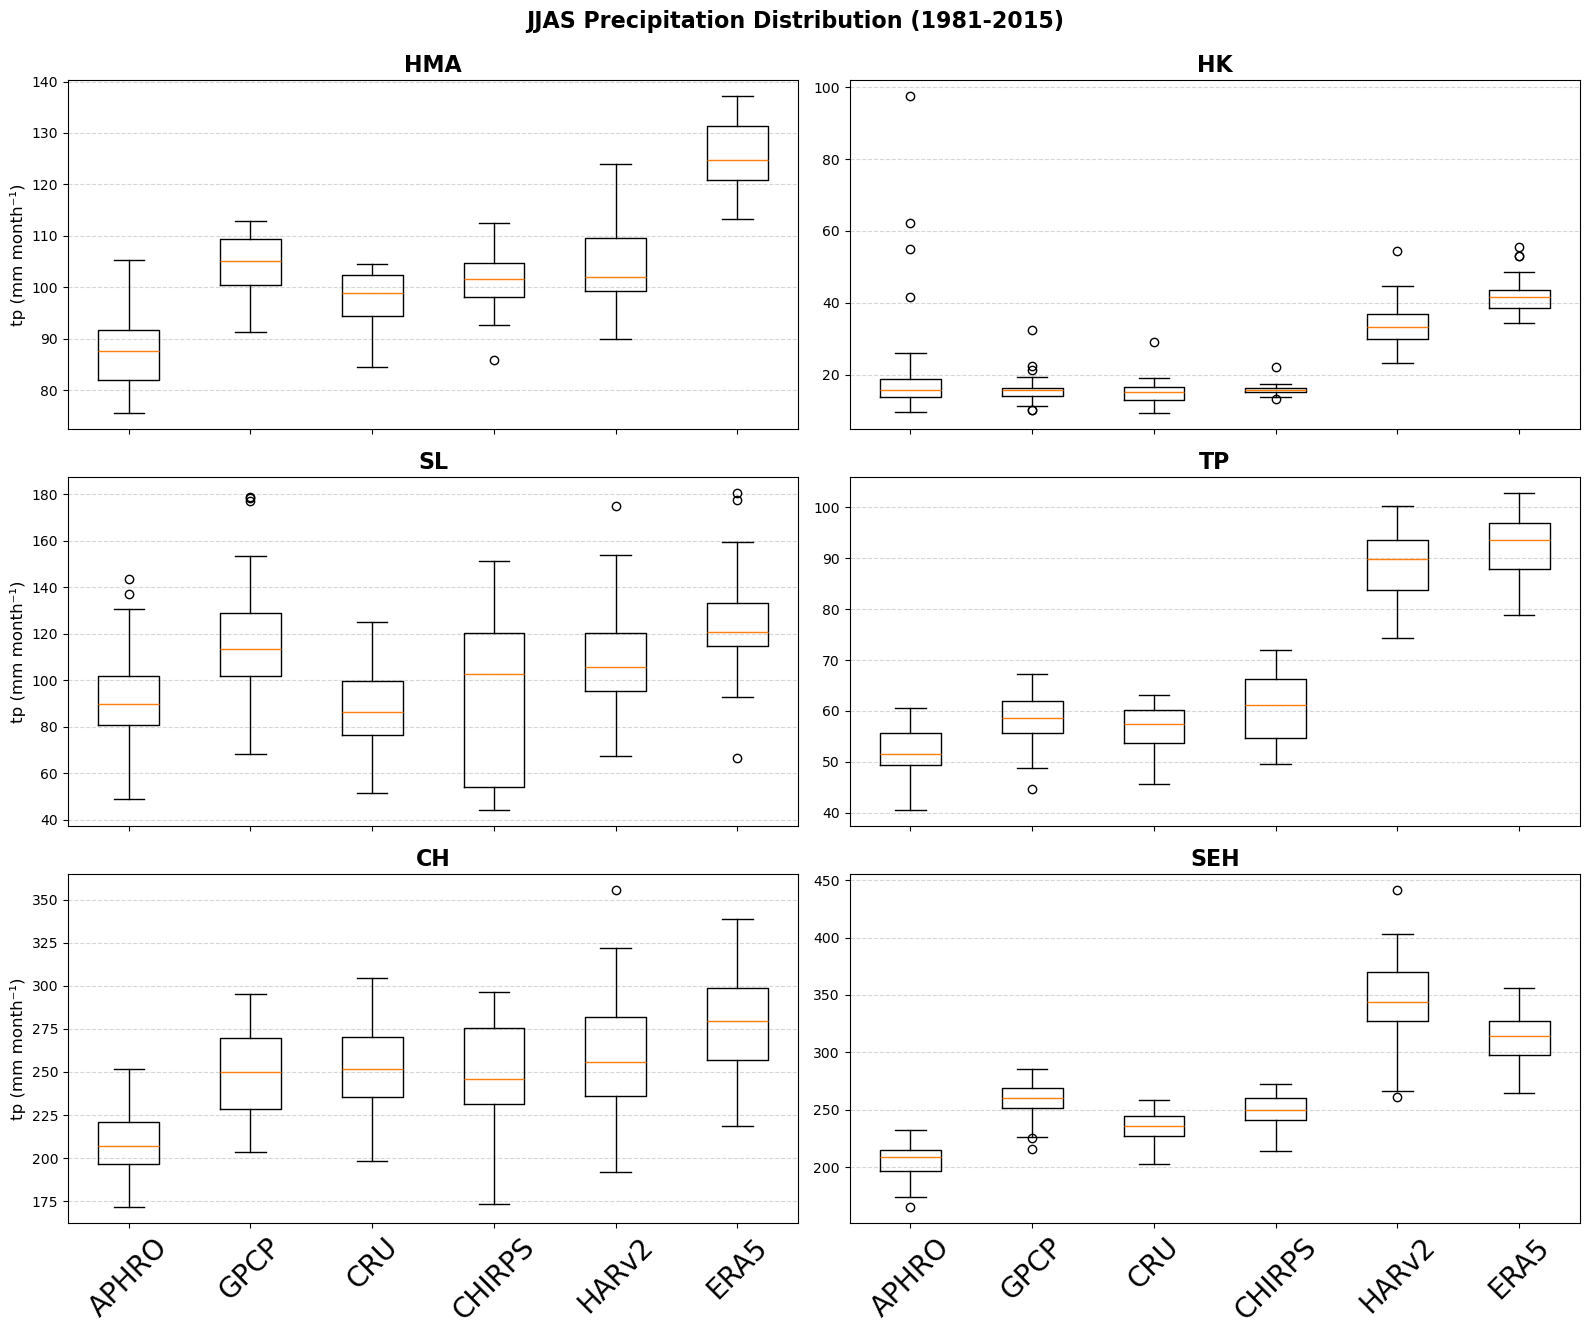

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(16,14))
axes = axes.flatten()

for i, dom in enumerate(domains):
    ax = axes[i]

    data_to_plot = []
    labels_to_plot = []

    for model in models:
        da = tp_datasets[model][dom]['tp']
        data_to_plot.append(da.values)
        labels_to_plot.append(model)

    # créer le boxplot
    bp = ax.boxplot(data_to_plot, tick_labels=labels_to_plot, patch_artist=False)

    # axes et style
    if i in [0, 2, 4]:
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
    if i in [4, 5]:
        ax.tick_params(labelbottom=True)
        ax.tick_params(axis='x', labelsize=20)
    if i in [0,1,2,3]:
        ax.tick_params(labelbottom=False)

    ax.set_title(dom, fontsize=16, weight='bold')
    ax.grid(True, linestyle='--', alpha=0.5, axis='y')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle(f'JJAS Precipitation Distribution ({iyear}-{fyear})', fontsize=16, weight='bold')
plt.tight_layout(rect=[0,0.03,1,0.95])
fig.subplots_adjust(top=0.93) 
plt.show()

# Trend plot

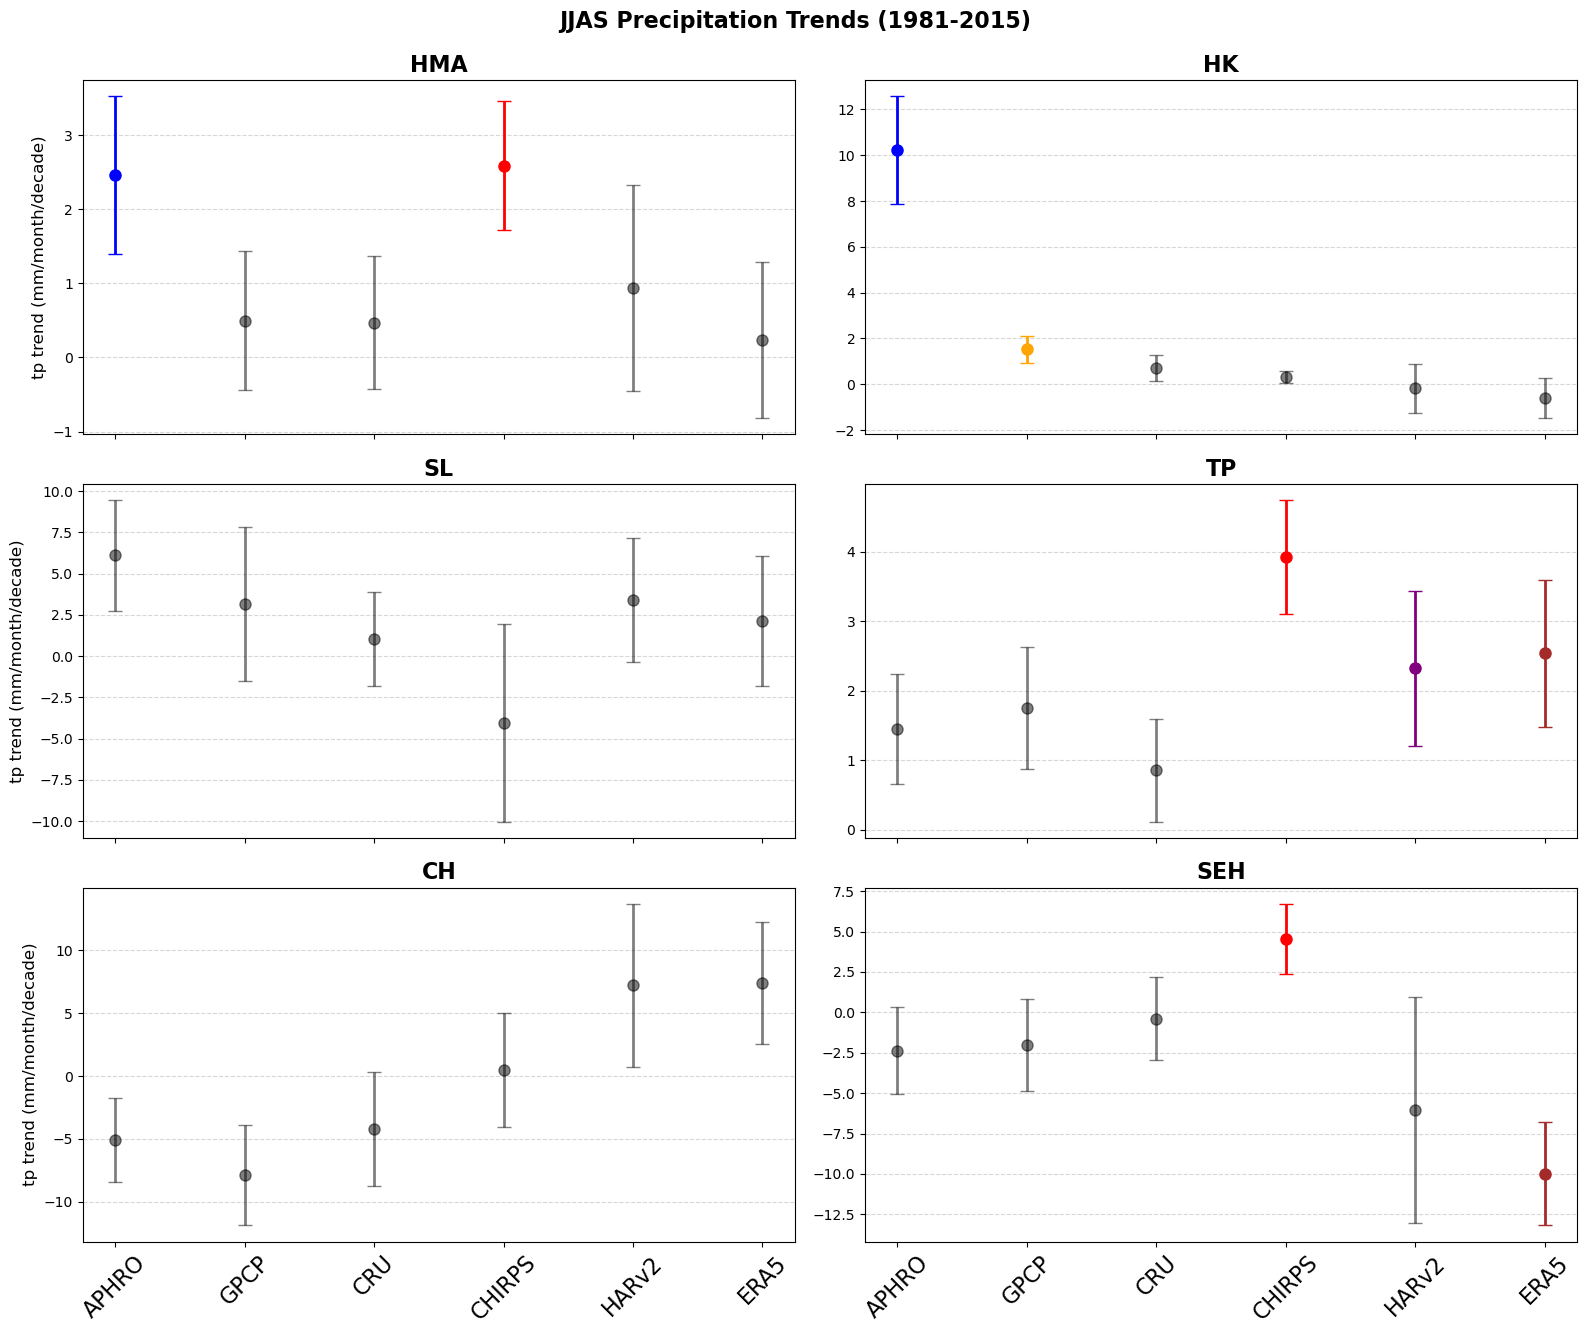

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(16,14))
axes = axes.flatten()

colors = {'APHRO':'blue', 'GPCP':'orange', 'CRU':'green',
          'CHIRPS':'red', 'HARv2':'purple', 'ERA5':'brown'}

for i, dom in enumerate(domains):
    ax = axes[i]

    x = range(1, len(models)+1)
    slopes = []
    errors = []

    for xi, model in zip(x, models):
        df = stats_datasets[model][dom]
        slope = df.loc[df['stat']=='slope', 'value'].values[0] *10
        std_err = df.loc[df['stat']=='std_err', 'value'].values[0] *10
        p_value = df.loc[df['stat']=='p_value', 'value'].values[0]

        if p_value <= 0.05:
            # plot point + barre d'erreur
            ax.errorbar(xi, slope, yerr=std_err, fmt='o', color=colors[model],
                        ecolor=colors[model], elinewidth=2, capsize=5, markersize=8)
        else:
            ax.errorbar(xi, slope, yerr=std_err, fmt='o', color='black',
                        ecolor='black', elinewidth=2, capsize=5, markersize=8, alpha=0.5)

    # axes et style
    if i in [0, 2, 4]:
        ax.set_ylabel('tp trend (mm/month/decade)', fontsize=12)
    if i in [4, 5]:
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=45, fontsize=16)
    if i in [0,1,2,3]:
        ax.tick_params(labelbottom=False)

    ax.set_title(dom, fontsize=16, weight='bold')
    ax.grid(True, linestyle='--', alpha=0.5, axis='y')

fig.suptitle(f'JJAS Precipitation Trends ({iyear}-{fyear})', fontsize=16, weight='bold')
plt.tight_layout(rect=[0,0.03,1,0.95])
fig.subplots_adjust(top=0.93)
plt.show()